In [15]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/panel/marz_year_panel_common.csv"
)

In [16]:
df.shape


(77, 24)

In [17]:
df.columns


Index(['marz', 'year', 'poverty_rate', 'extreme_poverty_rate', 'non_poor_rate',
       'population', 'crime_selected_total', 'Number of minor offense',
       'Number of moderately serious offense',
       'Number of particulary serious offences', 'crime_total',
       'Number of serious offences', 'Annual average occupancy of a bed',
       'Number of ambulatory clinics in rural communities',
       'Number of avarage medical personnel', 'beds',
       'Number of hospitalized patients', 'hospitals', 'Number of physicians',
       'Number of primary health care (PHC) service providers (except OMCs, private medical and dental offices)',
       'crime_rate_per_100k', 'crime_selected_rate_per_100k',
       'hospitals_per_100k', 'beds_per_10k'],
      dtype='object')

In [18]:
df.head()

,marz,year,poverty_rate,extreme_poverty_rate,non_poor_rate,population,crime_selected_total,Number of minor offense,Number of moderately serious offense,Number of particulary serious offences,...,Number of avarage medical personnel,beds,Number of hospitalized patients,hospitals,Number of physicians,"Number of primary health care (PHC) service providers (except OMCs, private medical and dental offices)",crime_rate_per_100k,crime_selected_rate_per_100k,hospitals_per_100k,beds_per_10k
0,Yerevan,2016,24.9,1.9,75.1,1073660.0,4085.0,4527.0,2917.0,95.0,...,8654.0,7924.0,279477.0,53.0,9504.0,147.0,869.828437,380.474266,4.936386,73.803625
1,Aragatsotn,2016,15.7,0.6,84.3,129774.0,191.0,322.0,259.0,4.0,...,633.0,200.0,5376.0,6.0,241.0,24.0,504.723596,147.178942,4.623422,15.411408
2,Ararat,2016,26.9,1.0,73.1,258911.0,349.0,647.0,417.0,4.0,...,1005.0,473.0,13693.0,7.0,460.0,60.0,473.135556,134.795354,2.703632,18.268826
3,Armavir,2016,30.0,1.5,70.0,266613.0,373.0,651.0,457.0,11.0,...,975.0,355.0,13364.0,4.0,403.0,61.0,490.598733,139.903156,1.500302,13.315180
4,Gegharkunik,2016,28.8,1.0,70.5,231794.0,156.0,414.0,320.0,5.0,...,941.0,750.0,12240.0,7.0,316.0,40.0,354.193810,67.301138,3.019923,32.356316


In [5]:
df.describe()[[
    "poverty_rate",
    "crime_rate_per_100k",
    "hospitals_per_100k",
    "beds_per_10k"
]]

,poverty_rate,crime_rate_per_100k,hospitals_per_100k,beds_per_10k
count,70.000000,70.000000,70.000000,70.000000
mean,26.002857,722.226161,4.336102,26.694441
std,10.680484,276.569849,1.556740,17.239148
min,2.800000,348.178456,1.134717,11.954761
25%,18.600000,544.494132,3.227489,17.183668
50%,24.550000,651.747139,4.758013,19.551620
75%,32.650000,836.155807,5.611981,30.912582
max,51.400000,1976.979771,6.686783,77.258437


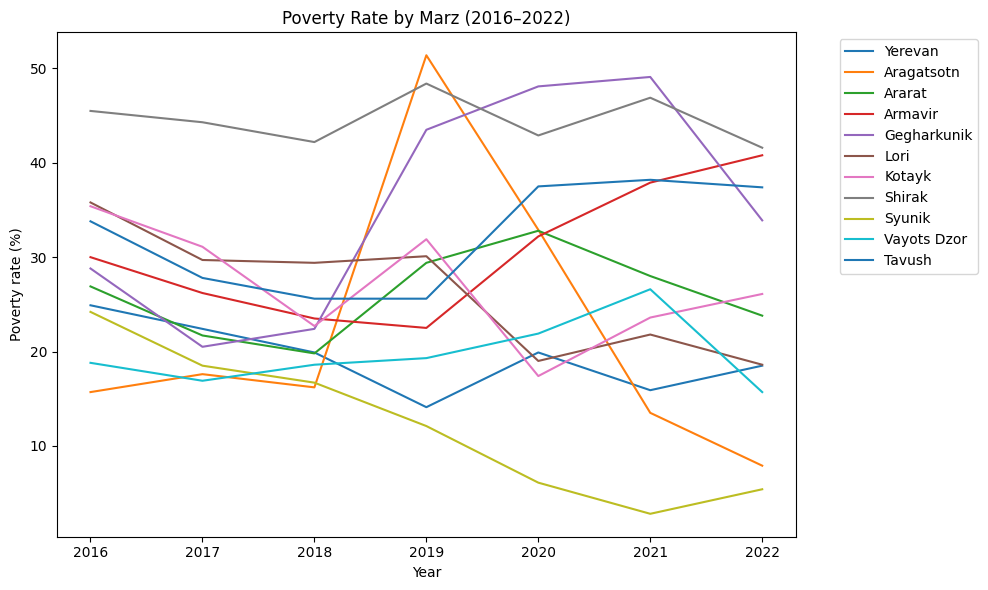

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for marz in df["marz"].unique():
    subset = df[df["marz"] == marz]
    plt.plot(subset["year"], subset["poverty_rate"], label=marz)

plt.title("Poverty Rate by Marz (2016–2022)")
plt.xlabel("Year")
plt.ylabel("Poverty rate (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


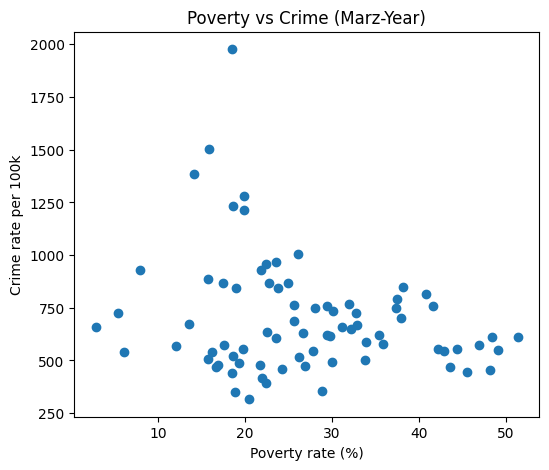

In [26]:
plt.figure(figsize=(6,5))
plt.scatter(df["poverty_rate"], df["crime_rate_per_100k"])

plt.xlabel("Poverty rate (%)")
plt.ylabel("Crime rate per 100k")
plt.title("Poverty vs Crime (Marz-Year)")
plt.show()


In [27]:
df[["poverty_rate", "crime_rate_per_100k"]].corr()


,poverty_rate,crime_rate_per_100k
poverty_rate,1.000000,-0.228138
crime_rate_per_100k,-0.228138,1.000000


In [28]:
from scipy.stats import zscore

df_stress = df.copy()

df_stress["z_poverty"] = zscore(df_stress["poverty_rate"])
df_stress["z_crime"] = zscore(df_stress["crime_rate_per_100k"])
df_stress["z_hospitals"] = zscore(df_stress["hospitals_per_100k"])

# invert health (higher capacity = less stress)
df_stress["z_health_inverted"] = -df_stress["z_hospitals"]


In [29]:
df_stress["stress_index"] = (
    df_stress["z_poverty"]
    + df_stress["z_crime"]
    + df_stress["z_health_inverted"]
)

# optional normalization (nice, not required)
df_stress["stress_index"] = zscore(df_stress["stress_index"])


In [30]:
df_stress.sort_values("stress_index", ascending=False).head(10)[
    ["marz", "year", "stress_index"]
]


,marz,year,stress_index
69,Armavir,2022,2.351567
66,Yerevan,2022,1.997088
58,Armavir,2021,1.762495
59,Gegharkunik,2021,1.411289
71,Lori,2022,1.329042
47,Armavir,2020,1.311384
46,Ararat,2020,1.180152
48,Gegharkunik,2020,1.138142
57,Ararat,2021,1.124899
68,Ararat,2022,1.102437


In [25]:
df_stress.sort_values("stress_index").head(10)[
    ["marz", "year", "stress_index"]
]


,marz,year,stress_index
9,Vayots Dzor,2016,-1.953942
52,Syunik,2020,-1.906789
63,Syunik,2021,-1.849577
20,Vayots Dzor,2017,-1.794759
53,Vayots Dzor,2020,-1.732771
42,Vayots Dzor,2019,-1.698652
31,Vayots Dzor,2018,-1.632321
74,Syunik,2022,-1.568355
41,Syunik,2019,-1.496462
30,Syunik,2018,-1.449321


In [31]:
df_stress.groupby("marz")["stress_index"].mean().sort_values(ascending=False)


marz
Armavir        1.197958
Lori           0.675064
Yerevan        0.661387
Ararat         0.616695
Gegharkunik    0.386076
Kotayk         0.343125
Shirak        -0.024801
Tavush        -0.304465
Aragatsotn    -0.467586
Syunik        -1.529009
Vayots Dzor   -1.554443
Name: stress_index, dtype: float64

In [32]:
df_stress.to_csv(
    "../data/processed/panel/marz_year_panel_common_with_stress.csv",
    index=False
)
